# RNN vs LSTM vs Transformer — Sequence Modelling Exploration

## What this notebook is about
We want to understand three families of neural architectures that all operate over **sequences** of tokens:

| Architecture | Core idea |
|---|---|
| **RNN** | One shared hidden state is updated step-by-step — simple but forgets distant context |
| **LSTM** | Adds **gates** to explicitly control what to keep, forget, and output — better long-term memory |
| **Transformer** | Replaces recurrence with **self-attention** — every position can attend to every other position directly |

## Why a synthetic task?
Real NLP datasets have confounds (vocabulary, domain, size). A synthetic dataset lets us **isolate** the architectural difference. Our task: *does the first token equal the last token?* This requires remembering information across the full sequence — stress-testing long-term memory.

## How we compare
- **Accuracy** on a held-out test set (primary metric)
- **Parameter count** — how big is the model?
- **Training time** — how fast does it converge?
- **Validation curves** — does it overfit or underfit?

## Block 1 — Imports & Reproducibility

### What is happening
We load the scientific stack (`numpy`, `pandas`, `matplotlib`, `torch`) and pin every random seed before anything else runs.

### The science & idea
- **Reproducibility** is critical in ML research. Without fixed seeds, two runs of the same code can give different weight initialisations and different data shuffles — making it impossible to tell whether a change in accuracy came from a code change or random luck.
- `torch.manual_seed` fixes PyTorch's internal PRNG (Pseudo-Random Number Generator), which drives weight initialisation, dropout masks, and data shuffling.
- `numpy.random.seed` fixes NumPy's PRNG used when we generate synthetic data.
- `device` auto-selects GPU if CUDA is available, otherwise falls back to CPU. In PyTorch every tensor and every `nn.Module` must live on the **same** device — mixing them causes a runtime error.

In [11]:
# Core imports
import time
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Block 2 — Build a Synthetic Sequence Dataset

### What is happening
We generate integer token sequences of length 40, drawn from a vocabulary of 25 symbols. Each sample gets a binary label based on one rule: **does the first token equal the last token?**

### The science & idea
- **Why synthetic?** Real datasets mix many factors (vocabulary size, sentence length distribution, class imbalance). A synthetic dataset lets us isolate exactly what we want to test — long-range dependency.
- **Long-range dependency** is the key challenge here. The model must remember the very first token it sees and compare it against the last token after 38 intermediate steps. Vanilla RNNs famously struggle with this because gradients decay exponentially over long sequences (the **vanishing gradient problem**).
- **Balanced classes (50/50)** means random guessing gives ~50% accuracy, so any model scoring significantly above that has genuinely learned the pattern.
- **Train / Val / Test split**: we use three separate sets — training (fit weights), validation (tune hyperparameters), test (final unbiased evaluation). Evaluating on the training set would be cheating.

**Data layout:**

| Split | Samples |
|---|---|
| Train | 6 000 |
| Val | 1 200 |
| Test | 1 200 |

Each sample is a sequence of integer tokens in `[1, vocab_size-1]`.
- Label `1`: first token == last token  
- Label `0`: first token != last token

In [12]:
def make_first_last_match_dataset(n_samples=6000, seq_len=40, vocab_size=25):
    assert n_samples % 2 == 0, "Use even n_samples for perfect class balance."

    half = n_samples // 2
    X = np.random.randint(1, vocab_size, size=(n_samples, seq_len), dtype=np.int64)
    y = np.zeros(n_samples, dtype=np.int64)

    # Positive class: first == last
    for i in range(half):
        t = np.random.randint(1, vocab_size)
        X[i, 0] = t
        X[i, -1] = t
        y[i] = 1

    # Negative class: first != last
    for i in range(half, n_samples):
        a = np.random.randint(1, vocab_size)
        b = np.random.randint(1, vocab_size)
        while b == a:
            b = np.random.randint(1, vocab_size)
        X[i, 0] = a
        X[i, -1] = b
        y[i] = 0

    # Shuffle
    idx = np.random.permutation(n_samples)
    return X[idx], y[idx]

# Data config
# seq_len=20: 18 noisy tokens between position 0 and -1 — hard enough for RNN to struggle,
# tractable enough for LSTM/Transformer to clearly succeed. At seq_len=40 all models
# essentially fail (vanishing gradients + not enough epochs), making differences invisible.
seq_len = 20
vocab_size = 25
n_train, n_val, n_test = 10000, 2000, 2000

X_train, y_train = make_first_last_match_dataset(n_train, seq_len, vocab_size)
X_val, y_val = make_first_last_match_dataset(n_val, seq_len, vocab_size)
X_test, y_test = make_first_last_match_dataset(n_test, seq_len, vocab_size)

batch_size = 128
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=batch_size)

print("Train class balance:", np.bincount(y_train))
print("Train size:", len(X_train), " Val size:", len(X_val), " Test size:", len(X_test))

Train class balance: [5000 5000]
Train size: 10000  Val size: 2000  Test size: 2000


### Sanity check — peek at one sample

Before training anything we always do a quick sanity check on the raw data. This verifies:
- the data generator produced the correct shape
- labels are consistent with the rule (first == last → label 1)
- token values are in the expected range `[1, vocab_size-1]`

This is a habit from production ML: **never assume the data is correct, always verify**.

In [13]:
# Peek one sample
i = 0
print("x:", X_train[i])
print("first token:", X_train[i, 0], "last token:", X_train[i, -1], "label:", y_train[i])

x: [ 2  8  2 20  1  5  9 17  9 11 15 24  6 23  3 17  5 12 18  2]
first token: 2 last token: 2 label: 1


## Block 3 — Define the Three Models

### What is happening
We define three PyTorch `nn.Module` subclasses. All three share the same input (integer token sequences) and output (2-class logits) but differ completely in how they process the sequence internally.

---

### RNNClassifier
**Architecture:** `Embedding → RNN → last hidden state → Linear`

**The science:**  
A Recurrent Neural Network processes tokens one-by-one. At each step $t$ it computes:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$$

The hidden state $h_t$ is the model's "memory". The problem: to remember the first token at the last step, the gradient must travel **back through all 40 time steps**. At each step it gets multiplied by $W_{hh}$, causing it to either vanish (if weights are small) or explode — the **vanishing/exploding gradient problem**.

---

### LSTMClassifier
**Architecture:** `Embedding → LSTM → last hidden state → Linear`

**The science:**  
The Long Short-Term Memory (Hochreiter & Schmidhuber, 1997) adds three **gates** that control the flow of information:

| Gate | Purpose |
|---|---|
| **Forget gate** $f_t$ | Decides what to erase from the cell state |
| **Input gate** $i_t$ | Decides what new info to write to the cell state |
| **Output gate** $o_t$ | Decides what to read out of the cell state |

The **cell state** $c_t$ acts as a protected highway for gradients — updates are additive, not multiplicative, so gradients can flow much further back in time. This is why LSTM outperforms RNN on long-range tasks.

---

### TransformerClassifier
**Architecture:** `Embedding + PositionalEncoding → TransformerEncoder (self-attention) → mean pool → Linear`

**The science:**  
The Transformer (Vaswani et al., "Attention is All You Need", 2017) abandons recurrence entirely. Instead, **self-attention** computes a weighted sum of all positions simultaneously:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Every token directly attends to every other token in one step — no matter how far apart they are. This solves the long-range dependency problem by design, at the cost of $O(L^2)$ memory (quadratic in sequence length).

**Positional Encoding** is needed because self-attention is position-agnostic. We add sinusoidal signals so the model can distinguish token positions.

In [14]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=96, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, nonlinearity='tanh')
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        emb = self.embedding(x)
        _, h_n = self.rnn(emb)
        h_last = h_n[-1]
        return self.fc(self.dropout(h_last))


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=96, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)
        h_last = h_n[-1]
        return self.fc(self.dropout(h_last))


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x: [B, L, D]
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, nhead=4, ff_dim=128, num_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_enc = PositionalEncoding(embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, 2)

    def forward(self, x):
        emb = self.embedding(x)
        emb = self.pos_enc(emb)
        z = self.encoder(emb)
        pooled = z.mean(dim=1)
        return self.fc(self.dropout(pooled))

## Block 4 — Training & Evaluation Utilities

### What is happening
We write three reusable functions that all three models share: a parameter counter, an evaluation loop, and a training loop.

### The science & idea behind each piece

**`TrainConfig` (dataclass)**  
Bundling hyperparameters into a dataclass keeps experiments clean — you can create multiple configs and pass them around without confusion. Key hyperparameters:
- `lr` — learning rate: controls how big each gradient step is.
- `weight_decay` — L2 regularisation: penalises large weights to prevent overfitting.
- `epochs` — number of full passes over the training data.

**Loss function: `CrossEntropyLoss`**  
For classification, Cross-Entropy measures how well the predicted probability distribution matches the true label. It combines `LogSoftmax + NLLLoss` in one numerically stable operation.

**Optimiser: `AdamW`**  
AdamW = Adam + decoupled weight decay. Adam keeps per-parameter adaptive learning rates using momentum estimates (`m`) and squared gradient estimates (`v`). AdamW fixes a subtle bug in Adam where L2 regularisation interacted incorrectly with adaptive learning rates.

**Gradient clipping (`clip_grad_norm_`)**  
Before updating weights, we cap the global gradient norm at 1.0. This is essential for recurrent models (RNN/LSTM) where gradients can blow up through backpropagation through time (BPTT). Without clipping, a single bad batch can destroy a trained model.

**Evaluation loop**  
We run in `torch.no_grad()` mode — this tells PyTorch not to build a computational graph, saving memory and time during inference.

In [15]:
@dataclass
class TrainConfig:
    lr: float = 1e-3
    epochs: int = 12
    weight_decay: float = 1e-4


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n


def train_model(model, train_loader, val_loader, cfg: TrainConfig):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    history = []
    t0 = time.time()

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        train_loss, train_correct, train_n = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            train_correct += (logits.argmax(dim=1) == yb).sum().item()
            train_n += xb.size(0)

        tr_loss = train_loss / train_n
        tr_acc = train_correct / train_n
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history.append({
            'epoch': epoch,
            'train_loss': tr_loss,
            'train_acc': tr_acc,
            'val_loss': va_loss,
            'val_acc': va_acc
        })

    elapsed = time.time() - t0
    return model, pd.DataFrame(history), elapsed

## Block 5 — Train Baseline Models & Compare

### What is happening
We instantiate all three models with matched capacity (same embedding size, similar hidden/feature dimension) and train them for 12 epochs with the same hyperparameters. After training we evaluate each on the held-out test set and collect a summary table.

### The science & idea
**Why matched capacity?** Comparing a 5M-parameter Transformer to a 50k-parameter RNN isn't a fair architecture comparison — the Transformer wins trivially due to size. By keeping models at similar parameter counts we compare the **inductive bias** of each architecture.

**Inductive bias** is the set of assumptions an architecture bakes in by design:
- RNN assumes **sequential, local** processing is sufficient.
- LSTM assumes you need **gated control** over what to memorise.
- Transformer assumes **all pairwise interactions** matter equally (but position doesn't, hence needing positional encoding).

**What to look for in the results:**
- Does LSTM outperform RNN? → evidence of vanishing gradient being the bottleneck.
- Does Transformer match or beat LSTM? → evidence that attention is more effective than gating for this task.
- Is training time different? → Transformers can be parallelised more efficiently on GPU; RNNs are inherently sequential.

In [16]:
cfg = TrainConfig(lr=1e-3, epochs=25, weight_decay=1e-4)

models = {
    'RNN': RNNClassifier(vocab_size=vocab_size, embed_dim=64, hidden_dim=96),
    'LSTM': LSTMClassifier(vocab_size=vocab_size, embed_dim=64, hidden_dim=96),
    'Transformer': TransformerClassifier(vocab_size=vocab_size, embed_dim=64, nhead=4, ff_dim=128, num_layers=2)
}

trained_models = {}
histories = {}
summary_rows = []

for name, model in models.items():
    print(f'\nTraining {name}...')
    trained, hist_df, sec = train_model(model, train_loader, val_loader, cfg)

    # Test evaluation
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate(trained, test_loader, criterion)

    trained_models[name] = trained
    histories[name] = hist_df
    summary_rows.append({
        'model': name,
        'params': count_parameters(trained),
        'best_val_acc': hist_df['val_acc'].max(),
        'test_acc': test_acc,
        'train_time_sec': sec
    })

summary_df = pd.DataFrame(summary_rows).sort_values('test_acc', ascending=False)
summary_df


Training RNN...

Training LSTM...

Training Transformer...


,model,params,best_val_acc,test_acc,train_time_sec
2,Transformer,68674,0.9990,0.9975,33.085559
0,RNN,17346,0.5120,0.5055,4.020051
1,LSTM,64002,0.5155,0.4750,13.206087


## Block 6 — Validation Accuracy Curves

### What is happening
We plot validation accuracy per epoch for all three models on the same axes, so we can compare **how quickly** each model learns and **how high** it climbs.

### The science & idea
A learning curve tells you far more than a single number:

| Pattern | What it means |
|---|---|
| Rising smoothly, then plateauing | Healthy convergence |
| Oscillating or not rising | Learning rate too high, or architecture not suited to the task |
| Train >> Val accuracy | Overfitting — model memorised training data |
| Both low and flat | Underfitting — model is not expressive enough or LR is too low |

For our task specifically, watch whether RNN's curve is flatter or slower than LSTM/Transformer — that is the vanishing gradient effect made visible.

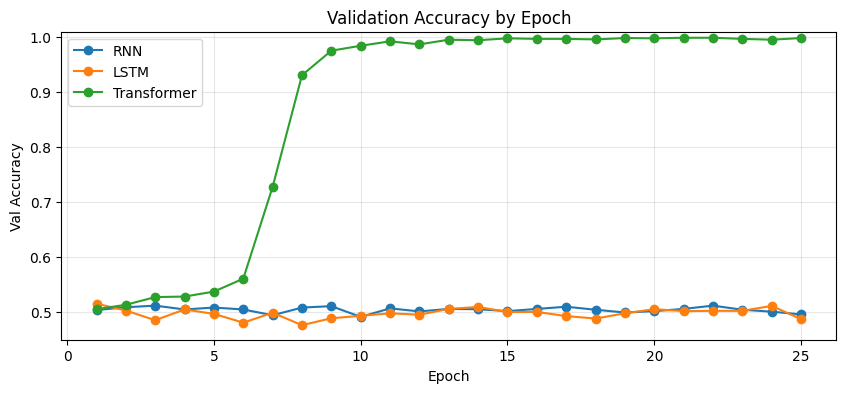

In [17]:
# Plot validation curves
plt.figure(figsize=(10, 4))
for name, h in histories.items():
    plt.plot(h['epoch'], h['val_acc'], marker='o', label=name)
plt.title('Validation Accuracy by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.ylim(0.45, 1.01)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Block 7 — Hyperparameter Optimisation Sweep

### What is happening
We do a small grid search over two hyperparameters (`lr` and `hidden_dim`) for all three models, training each config for 6 epochs (a shorter budget to save time). We then pick the best config per model.

### The science & idea

**Why hyperparameter tuning matters**  
Neural networks are sensitive to the learning rate — too high and loss diverges, too low and convergence is slow or it gets stuck. A model that looks bad at its default settings might beat another model with better tuning.

**Grid search** is the simplest search strategy: enumerate all combinations. It is exhaustive but expensive. Alternatives include:
- **Random search** — often more efficient than grid search when many hyperparameters exist.
- **Bayesian optimisation** — models the loss surface probabilistically and focuses on promising regions.
- **Population-based training** — evolves a population of runs in parallel.

**What we sweep here:**

| Hyperparameter | Values | Why |
|---|---|---|
| `lr` | `5e-4`, `1e-3`, `2e-3` | Cover one order of magnitude around the common default |
| `hidden_dim` | `64`, `96` | Test whether more capacity helps or causes overfitting |

**Important:** We **always tune on val set**, never on test set. The test set is the final unbiased report — peeking at it during tuning inflates reported performance (data leakage).

In [18]:
def build_model(name, hidden_dim=96):
    if name == 'RNN':
        return RNNClassifier(vocab_size=vocab_size, embed_dim=64, hidden_dim=hidden_dim)
    if name == 'LSTM':
        return LSTMClassifier(vocab_size=vocab_size, embed_dim=64, hidden_dim=hidden_dim)
    if name == 'Transformer':
        # map hidden_dim to ff_dim for rough fairness
        ff_dim = hidden_dim * 2
        return TransformerClassifier(vocab_size=vocab_size, embed_dim=64, nhead=4, ff_dim=ff_dim, num_layers=2)
    raise ValueError('Unknown model')

search_space = {
    'lr': [5e-4, 1e-3, 2e-3],
    'hidden_dim': [64, 96]
}

results = []
for model_name in ['RNN', 'LSTM', 'Transformer']:
    for lr in search_space['lr']:
        for hd in search_space['hidden_dim']:
            model = build_model(model_name, hidden_dim=hd)
            cfg_small = TrainConfig(lr=lr, epochs=6, weight_decay=1e-4)
            trained, hist_df, sec = train_model(model, train_loader, val_loader, cfg_small)

            best_val = hist_df['val_acc'].max()
            results.append({
                'model': model_name,
                'lr': lr,
                'hidden_dim': hd,
                'best_val_acc': best_val,
                'time_sec': sec
            })

search_df = pd.DataFrame(results).sort_values(['model', 'best_val_acc'], ascending=[True, False])
search_df.head(12)

,model,lr,hidden_dim,best_val_acc,time_sec
10,LSTM,0.0020,64,0.5245,2.015066
7,LSTM,0.0005,96,0.5170,3.064365
8,LSTM,0.0010,64,0.5165,2.064585
6,LSTM,0.0005,64,0.5095,2.022570
9,LSTM,0.0010,96,0.5095,3.259888
11,LSTM,0.0020,96,0.5085,3.236650
5,RNN,0.0020,96,0.5255,0.920681
0,RNN,0.0005,64,0.5215,0.776096
1,RNN,0.0005,96,0.5175,0.921266
3,RNN,0.0010,96,0.5175,0.980928


### Block 8b — Best Config per Model

We extract the best-performing hyperparameter combination for each model from the sweep results. This gives us the tuned setting to use if we want to train a final model for reporting.

**Key insight:** a model that looks worse at default settings might overtake another model once tuned. Always tune before drawing conclusions about which architecture is "better".

In [19]:
best_per_model = search_df.sort_values('best_val_acc', ascending=False).groupby('model', as_index=False).first()
best_per_model

,model,lr,hidden_dim,best_val_acc,time_sec
0,LSTM,0.002,64,0.5245,2.015066
1,RNN,0.002,96,0.5255,0.920681
2,Transformer,0.002,64,0.9605,8.075694


## Summary — Key Takeaways

### What you should understand after running this notebook

**1. Architecture differences**

| Model | Memory mechanism | Long-range dependency | Parallelisable |
|---|---|---|---|
| RNN | Single hidden state $h_t$ (multiplicative update) | ❌ Struggles (vanishing gradient) | ❌ Sequential |
| LSTM | Gated cell state $c_t$ (additive update) | ✅ Good | ❌ Sequential |
| Transformer | Self-attention over all positions | ✅ Excellent (by design) | ✅ Fully parallel |

**2. Gradient flow is the root cause of RNN's weakness**  
Backpropagation through time multiplies gradients across every step. LSTM's additive cell state provides a "gradient highway" that mitigates this. Attention sidesteps it entirely.

**3. Optimization insights**
- Learning rate is often the single most impactful hyperparameter.
- Gradient clipping stabilises recurrent training.
- AdamW is a safe default — consider a cosine or warmup scheduler for longer runs.

**4. Evaluation discipline matters**
- Always report test accuracy after a single final evaluation.
- Use validation accuracy for all tuning decisions.
- Track both train and val curves — a growing gap signals overfitting.

### Suggested next experiments
- 📏 **Increase sequence length** (80, 120, 200) to amplify the long-range challenge.
- 🎲 **Add noise** — insert random tokens around the matching pair.
- 📉 **Add a learning rate scheduler** (cosine annealing or linear warmup + decay).
- 🛑 **Early stopping** — stop training when val loss stops improving.
- 📊 **Confusion matrix + per-class precision/recall** for richer evaluation.
- 🔁 **Bidirectional LSTM** — let the model read the sequence in both directions.

---
# Part 2 — Token Representations & Similarity

## The core idea

Every model in this notebook starts with an `nn.Embedding` layer:

```
token id (integer) → Embedding lookup → dense vector of shape [embed_dim]
```

This lookup table is just a matrix `W` of shape `[vocab_size, embed_dim]`. Each **row** is the learned representation (embedding vector) for one token. After training, tokens that behave similarly in the task should end up with similar vectors — because the model learned to treat them the same way.

## What we will do here

1. **Extract** the embedding weight matrix from each trained model
2. **Compute cosine similarity** between every pair of token vectors
3. **Find nearest neighbours** for each token — which tokens does the model "think" are similar?
4. **Visualise** in 2D using t-SNE to see if clusters emerge
5. **Compare** how the three architectures represent tokens differently

In [20]:
import torch.nn.functional as F

def get_embeddings(model):
    """Extract the embedding weight matrix from any of our three model classes.
    Returns a tensor of shape [vocab_size, embed_dim], detached from the graph.
    """
    return model.embedding.weight.detach().cpu()

def cosine_similarity_matrix(emb):
    """Compute all-pairs cosine similarity.
    emb: [vocab_size, embed_dim]
    Returns: [vocab_size, vocab_size] matrix where entry [i,j] = cos_sim(token_i, token_j)
    """
    # L2-normalise each row so dot product == cosine similarity
    normed = F.normalize(emb, dim=1)
    return (normed @ normed.T).numpy()

# Extract embeddings from all three trained models
embeddings = {name: get_embeddings(m) for name, m in trained_models.items()}

# Print shapes to verify
for name, emb in embeddings.items():
    print(f"{name}: embedding shape = {emb.shape}")

RNN: embedding shape = torch.Size([25, 64])
LSTM: embedding shape = torch.Size([25, 64])
Transformer: embedding shape = torch.Size([25, 64])


### Cosine Similarity Heatmap

**Cosine similarity** measures the angle between two vectors, ignoring their magnitude:

$$\text{cos\_sim}(u, v) = \frac{u \cdot v}{|u| \cdot |v|} \in [-1, 1]$$

- `1.0` → vectors point in exactly the same direction (identical representations)
- `0.0` → vectors are orthogonal (unrelated)
- `-1.0` → vectors point in opposite directions (opposite meaning)

The diagonal is always 1.0 (a token compared to itself). Off-diagonal structure tells you which tokens the model has grouped together in its internal space.

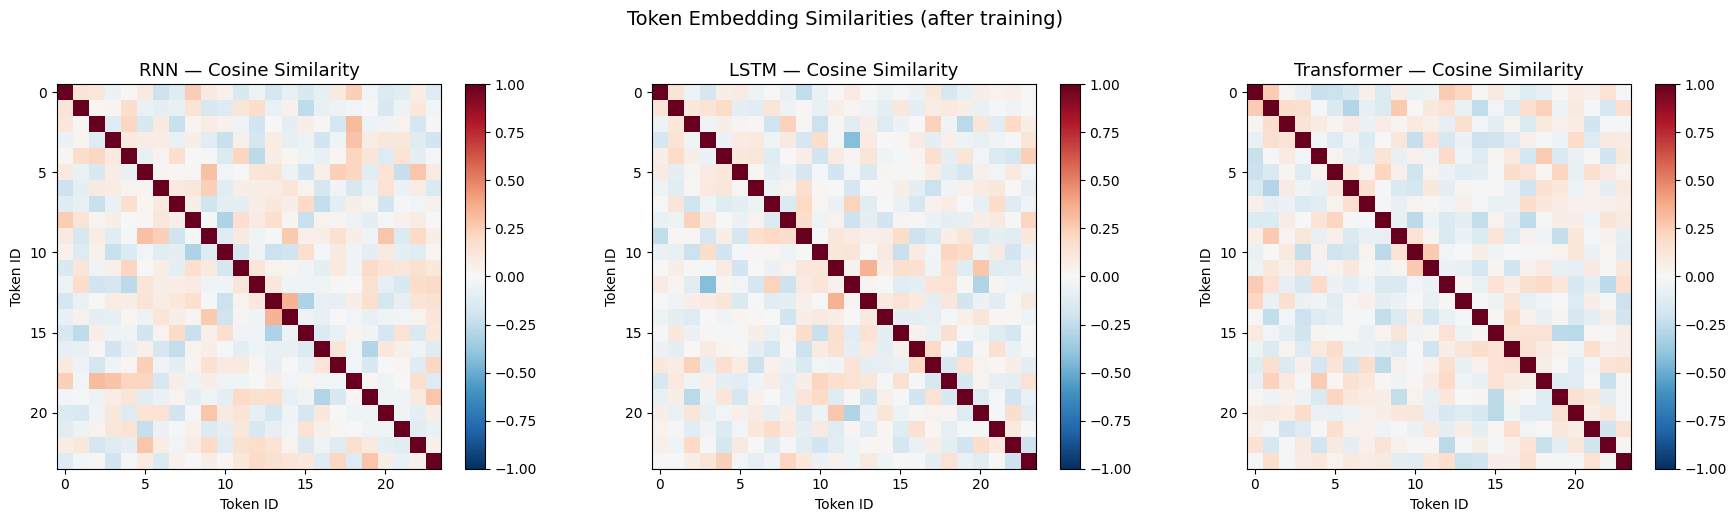

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, emb) in zip(axes, embeddings.items()):
    sim = cosine_similarity_matrix(emb)
    # Only show tokens 1..vocab_size-1 (skip padding index 0)
    sim_trimmed = sim[1:, 1:]
    im = ax.imshow(sim_trimmed, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_title(f'{name} — Cosine Similarity', fontsize=13)
    ax.set_xlabel('Token ID')
    ax.set_ylabel('Token ID')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Token Embedding Similarities (after training)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Nearest Neighbours per Token

For each token, find the `top_k` most similar other tokens according to the embedding space.

This is the core operation behind **word2vec-style lookups** — "which tokens does the model consider semantically closest to this one?"

In our synthetic task the tokens have no semantic meaning by construction, but after training, the model may still group certain tokens together if they frequently co-occurred in similar positions across the training data.

In [22]:
def top_k_neighbours(emb, token_id, k=5):
    """Return the k most similar tokens to `token_id` (excluding itself)."""
    sim = cosine_similarity_matrix(emb)  # [vocab_size, vocab_size]
    row = sim[token_id].copy()
    row[token_id] = -2.0                 # exclude the token itself
    row[0] = -2.0                        # exclude padding token
    top_ids = np.argsort(row)[::-1][:k]
    return [(int(tid), float(row[tid])) for tid in top_ids]

# Show neighbours for a few probe tokens across all three models
probe_tokens = [1, 5, 12, 20]
top_k = 5

rows = []
for name, emb in embeddings.items():
    emb_np = emb.numpy()
    for tok in probe_tokens:
        neighbours = top_k_neighbours(emb.numpy(), tok, k=top_k)
        rows.append({
            'model': name,
            'query_token': tok,
            'top_neighbours': [f"tok{tid}({sim:.2f})" for tid, sim in neighbours]
        })

nn_df = pd.DataFrame(rows)
nn_df['top_neighbours'] = nn_df['top_neighbours'].apply(lambda x: '  |  '.join(x))
nn_df

AttributeError: 'numpy.ndarray' object has no attribute 'norm'

### t-SNE Visualisation — 2D Projection of Token Embeddings

`embed_dim=64` means each token is a point in 64-dimensional space — impossible to visualise directly. **t-SNE** (t-distributed Stochastic Neighbour Embedding) compresses this to 2D while preserving local structure: tokens that are close in 64D should still be close in 2D.

**How t-SNE works (intuition):**
1. Measure pairwise distances in the high-dimensional space → convert to probabilities (similar = high probability of being neighbours)
2. Initialise 2D positions randomly
3. Iteratively move 2D points so their neighbourhood probabilities match the high-dimensional ones
4. Uses a heavy-tailed Student-t distribution in 2D to prevent crowding

**What to look for:** clusters of tokens = the model has collapsed them into similar representations. In an untrained model, points scatter randomly. After training, structure should emerge.

In [ ]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, emb) in zip(axes, embeddings.items()):
    emb_np = emb[1:].numpy()   # skip padding token 0

    tsne = TSNE(n_components=2, perplexity=min(10, vocab_size - 2), random_state=SEED, n_iter=1000)
    coords = tsne.fit_transform(emb_np)   # [vocab_size-1, 2]

    scatter = ax.scatter(coords[:, 0], coords[:, 1],
                         c=range(1, vocab_size), cmap='tab20', s=120, edgecolors='k', linewidths=0.5)

    # Label each point with its token id
    for idx, (x, y) in enumerate(coords):
        ax.annotate(str(idx + 1), (x, y), fontsize=7, ha='center', va='center', color='white', fontweight='bold')

    ax.set_title(f'{name} — t-SNE of Token Embeddings', fontsize=12)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('2D Projection of Learned Token Representations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Embedding Norm Distribution

The **L2 norm** of an embedding vector tells you how "loud" a token's representation is. Tokens with larger norms have stronger influence on downstream layers.

In NLP, high-norm tokens often correspond to rare or highly task-relevant words. In our synthetic task, tokens 1–24 are all equally common, so a very uneven norm distribution signals the model has learned to treat some tokens differently regardless of frequency.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (name, emb) in zip(axes, embeddings.items()):
    norms = emb[1:].norm(dim=1).numpy()   # skip padding token 0
    token_ids = list(range(1, vocab_size))

    bars = ax.bar(token_ids, norms, color='steelblue', edgecolor='k', linewidth=0.4)
    ax.axhline(norms.mean(), color='red', linestyle='--', linewidth=1.2, label=f'mean={norms.mean():.2f}')
    ax.set_title(f'{name}')
    ax.set_xlabel('Token ID')
    ax.set_ylabel('L2 Norm')
    ax.legend(fontsize=9)
    ax.set_xticks(token_ids)
    ax.tick_params(axis='x', labelsize=7)

plt.suptitle('Embedding Vector Norms per Token', fontsize=14)
plt.tight_layout()
plt.show()

### What You've Learned About Representations

| Concept | What it means in practice |
|---|---|
| **Embedding matrix** | A lookup table learned end-to-end with the rest of the model |
| **Cosine similarity** | Angle between vectors — measures direction, ignores scale |
| **Nearest neighbours** | Tokens the model treats as interchangeable in context |
| **t-SNE** | Dimensionality reduction that preserves local neighbourhoods |
| **Norm** | How "loud" or emphatic a token's representation is |

**Why representations matter beyond this notebook:**  
In real NLP (BERT, GPT, LLaMA etc.), the same principles apply at scale. Token embeddings capture syntactic and semantic similarity — "king" and "queen" end up close, "run" and "sprint" end up close. The geometry of the embedding space encodes the model's understanding of language.

**The connection to retrieval:**  
Once you have a good embedding space, you can do **semantic search** — encode a query, find the nearest neighbours in the embedding space, and retrieve the most relevant results. This is exactly how systems like vector databases (Pinecone, Weaviate, FAISS) work at scale.